In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import opytional as opyt
import pandas as pd
import polars as pl
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-09-06T01:45:25.568476+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

polars   : 1.29.0
teeplot  : 1.4.2
numpy    : 2.1.2
scipy    : 1.14.1
seaborn  : 0.13.2
opytional: 0.1.0
pandas   : 2.2.3

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-freqscreen-summary"
teeplot_subdir


'2025-05-19-freqscreen-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "dummy": "https://osf.io/cjqx2/download",
    "uk-big": "https://osf.io/pgj7t/download",
    "uk": "https://osf.io/mkjy5/download",
    "multistrain": "https://osf.io/ywmpt/download",
    "vanilla": "https://osf.io/r8skg/download",
    "vanilla-big": "https://osf.io/j4795/download",
    "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        phylo_df = (
            df.filter(
                (pl.col("trt_name") == trt_name)
                & (pl.col("trt_n_downsample") == trt_n_downsample)
                & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
                & (pl.col("replicate_uuid") == replicate_uuid)
            )
            .collect(engine="streaming")
            .to_pandas()
        )

        num_muts = phylo_df["defmut_mask_sum"].astype(bool).sum()
        num_focal_muts = phylo_df["is_focal_defmut"].sum()
        num_bg_sites = phylo_df["cfg_maxseqlen"].unique().item()

        expected_num_muts = (
            phylo_df["defmut_mask_sum"].sum() - num_focal_muts
        ) / num_bg_sites

        lambda_poisson = expected_num_muts
        p_poisson = scipy_stats.poisson.sf(num_focal_muts, lambda_poisson)

        results.append(
            {
                "source_name": source_name,
                "trt_name": trt_name,
                "trt_n_downsample": trt_n_downsample,
                "trt_hsurf_bits": trt_hsurf_bits,
                "replicate_uuid": replicate_uuid,
                "num_muts": num_muts,
                "num_focal_muts": num_focal_muts,
                "num_bg_sites": num_bg_sites,
                "expected_num_muts": expected_num_muts,
                "p_poisson": p_poisson,
                "lambda_poisson": lambda_poisson,
            }
        )


--2026-09-06 01:45:25--  https://osf.io/pgj7t/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://osf.io/download/pgj7t [following]
--2026-09-06 01:45:26--  https://osf.io/download/pgj7t
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://osf.io/download/pgj7t/ [following]
--2026-09-06 01:45:26--  https://osf.io/download/pgj7t/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 Found
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682d5f8cc1a255a482f08030 [following]
--2026-09-06 01:45:26--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682d5f8cc1a255a482f08030
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP reques

done!


100%|██████████| 70/70 [01:19<00:00,  1.13s/it]
--2026-09-06 01:47:16--  https://osf.io/mkjy5/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 

301 Moved Permanently
Location: https://osf.io/download/mkjy5 [following]
--2026-09-06 01:47:17--  https://osf.io/download/mkjy5
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://osf.io/download/mkjy5/ [following]
--2026-09-06 01:47:17--  https://osf.io/download/mkjy5/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 Found
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682c8b8ca9789d8b628f3f38 [following]
--2026-09-06 01:47:17--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682c8b8ca9789d8b628f3f38
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://storage.googleapis.com/cos-osf-prod-files-us-east1/287d491af51f17bc5f99c562c1317362a49cd5cc49427ab35d08356a2a557cf0?response-content-disposition

done!


...

done!


100%|██████████| 18/18 [00:14<00:00,  1.25it/s]
--2026-09-06 01:51:08--  https://osf.io/cnp5z/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 

301 Moved Permanently
Location: https://osf.io/download/cnp5z [following]
--2026-09-06 01:51:08--  https://osf.io/download/cnp5z
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://osf.io/download/cnp5z/ [following]
--2026-09-06 01:51:08--  https://osf.io/download/cnp5z/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 Found
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682caa9fbb3f815770b06c6b [following]
--2026-09-06 01:51:08--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682caa9fbb3f815770b06c6b
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://storage.googleapis.com/cos-osf-prod-files-us-east1/2699685afb8432314e32aeb42461c6e793a5657919f106fac95e2c3836dcd309?response-content-disposition

done!


100%|██████████| 20/20 [00:22<00:00,  1.12s/it]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,num_muts,num_focal_muts,num_bg_sites,expected_num_muts,p_poisson,lambda_poisson
0,uk-big,Sben2x/Gneu,1000000,0,2232bc33-f7a5-8331-8604-3ba752815582,3123,2598,19.0,28.263158,0.000000e+00,28.263158
1,uk-big,Sben1.1x/Gdel1.1x,1000000,64,22ce47ac-0205-87ef-97f7-1e6e1a4ae8a3,502,8,19.0,26.000000,9.999626e-01,26.000000
2,uk-big,Sben2x/Gdel2x,1000000,64,02e78687-647f-8589-871d-69d40c582380,1741,1244,19.0,26.315789,0.000000e+00,26.315789
3,uk-big,Sben2x/Gneu,1000000,0,45915ee2-af31-8bc0-94c2-64fb711075ad,2990,2502,19.0,25.947368,0.000000e+00,25.947368
4,uk-big,Sben2x/Gneu,1000000,64,45915ee2-af31-8bc0-94c2-64fb711075ad,2464,1961,19.0,27.000000,0.000000e+00,27.000000
...,...,...,...,...,...,...,...,...,...,...,...
242,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,200000,0,c81cab91-5dfe-83d3-a088-110240579728,1185,237,19.0,50.105263,1.156350e-81,50.105263
243,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,200000,0,c8b6eec3-f562-8a2a-a720-f23d4acf1d94,1189,258,19.0,49.105263,3.968153e-98,49.105263
244,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,488c314a-7dbc-88f3-aa36-beada5f1bb05,6215,1807,19.0,232.631579,0.000000e+00,232.631579
245,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,200000,0,2b2da60e-53a7-8888-9058-ce1b89fb83e3,1196,272,19.0,48.736842,3.772233e-109,48.736842


In [9]:
results_df.groupby(
    ["source_name", "trt_name", "trt_n_downsample", "trt_hsurf_bits"]
).agg(
    {
        "num_focal_muts": ["mean", "std"],
        "num_bg_sites": ["mean", "std"],
        "expected_num_muts": ["mean", "std"],
    }
)


num_focal_muts  \
                                                                             mean   
source_name      trt_name          trt_n_downsample trt_hsurf_bits                  
multistrain      Sben1.1x/Gdel1.1x 1000000          0                   25.500000   
                 Sben1.1x/Gneu     1000000          0                   29.400000   
                 Sben1.3x/Gdel1.3x 1000000          0                  297.200000   
                 Sben1.3x/Gneu     1000000          0                  423.000000   
                 Sben2x/Gdel2x     1000000          0                 5630.400000   
                 Sben2x/Gneu       1000000          0                 9488.400000   
                 Sneu/Gneu         1000000          0                   16.600000   
uk               Sben1.1x/Gdel1.1x 1000000          0                    1.400000   
                                                    64                   1.200000   
                 Sben1.1x/Gneu     1000000          0                    1.200000   
                                                    64                   1.000000   
                 Sben1.3x/Gdel1.3x 1000000          0                   13.800000   
                                                    64                   9.000000   
                 Sben1.3x/Gneu     1000000          0                   13.400000   
                                                    64                  10.400000   
                 Sben2x/Gdel2x     1000000          0                  275.200000   
                                                    64                 210.200000   
                 Sben2x/Gneu       1000000          0                  510.000000   
                                                    64                 348.600000   
                 Sneu/Gneu         1000000          0                    1.000000   
                                                    64                   0.600000   
uk-big           Sben1.1x/Gdel1.1x 1000000          0                    7.200000   
                                                    64                   6.600000   
                 Sben1.1x/Gneu     1000000          0                    7.000000   
                                                    64                   6.400000   
                 Sben1.3x/Gdel1.3x 1000000          0                   58.400000   
                                                    64                  53.600000   
                 Sben1.3x/Gneu     1000000          0                   91.000000   
                                                    64                  78.200000   
                 Sben2x/Gdel2x     1000000          0                 1419.200000   
                                                    64                1185.600000   
                 Sben2x/Gneu       1000000          0                 2569.200000   
                                                    64                2043.400000   
                 Sneu/Gneu         1000000          0                    5.400000   
                                                    64                   5.800000   
vanilla          Sben1.1x/Gdel1.1x 1000000          0                   18.400000   
                 Sben1.1x/Gneu     1000000          0                   21.200000   
                 Sben1.3x/Gdel1.3x 1000000          0                  361.400000   
                 Sben1.3x/Gneu     1000000          0                  465.600000   
                 Sben2x/Gdel2x     1000000          0                 6679.000000   
                 Sben2x/Gneu       1000000          0                 8493.200000   
                 Sneu/Gneu         1000000          0                   14.800000   
vanilla-big      Sben1.1x/Gdel1.1x 200000           0                   17.333333   
                                                    64                  12.666667   
                                   2000000          0                   

In [10]:
results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+row_order=vanilla_uk-big_multistrain+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+row_order=vanilla_uk-big_multistrain+viz=catplot+y=p-poisson+ext=.png


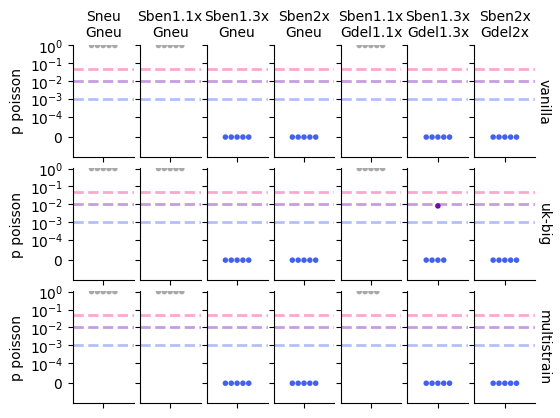

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+row_order=None+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+row_order=None+viz=catplot+y=p-poisson+ext=.png


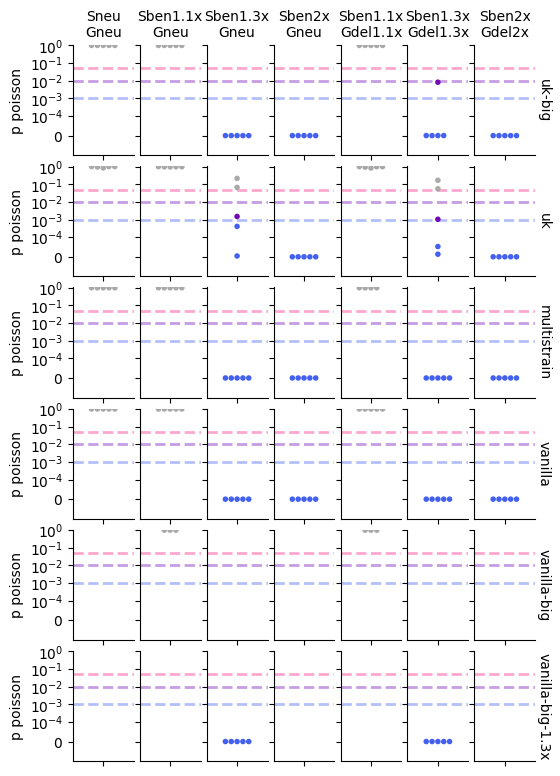

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=multistrain+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=multistrain+viz=catplot+y=p-poisson+ext=.png


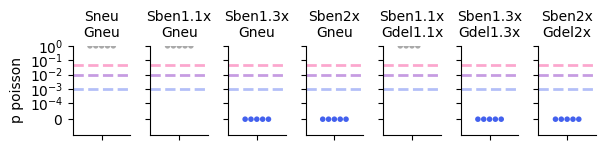

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk+viz=catplot+y=p-poisson+ext=.png


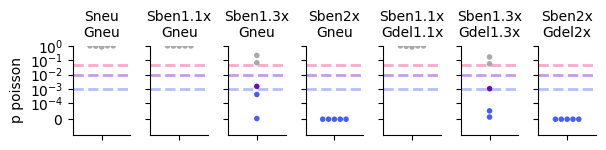

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk-big+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=uk-big+viz=catplot+y=p-poisson+ext=.png


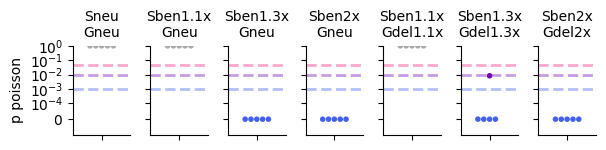

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla+viz=catplot+y=p-poisson+ext=.png


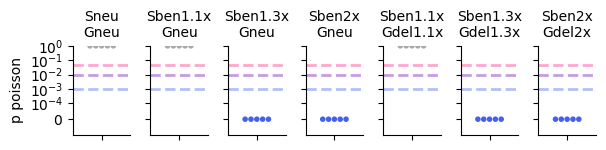

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big+viz=catplot+y=p-poisson+ext=.png


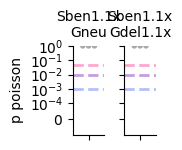

teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=p-poisson+ext=.png


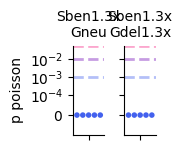

In [11]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in ("p_poisson",):
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df.groupby(["trt_name", "source_name"])[
                "trt_n_downsample"
            ].transform("max")
        )
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    for row_order in ["vanilla", "uk-big", "multistrain"], None:
        with tp.teed(
            sns.catplot,
            data=data,
            y=y,
            col="trt_name_",
            row="source_name",
            row_order=row_order,
            hue="sig",
            col_order=col_order,
            legend=False,
            kind="swarm",
            margin_titles=True,
            height=1.55,
            aspect=0.55,
            size=4,
            palette=gentle_palette,
            facet_kws=dict(gridspec_kws=dict(hspace=0.1, wspace=0.1)),
            teeplot_outattrs={"row_order": opyt.apply_if(row_order, "_".join)},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            teed.set_titles(
                col_template="{col_name}", row_template="{row_name}"
            )
            for ax in teed.axes.flat:
                ax.set_yscale("symlog", linthresh=0.0001)
                ax.set_ylim(-0.0001, None)
                ax.axhline(
                    0.05,
                    alpha=0.4,
                    color=gentle_palette[2],
                    linestyle="--",
                    linewidth=2,
                )
                ax.axhline(
                    0.01,
                    alpha=0.4,
                    color=gentle_palette[1],
                    linestyle="--",
                    linewidth=2,
                )
                ax.axhline(
                    0.001,
                    alpha=0.4,
                    color=gentle_palette[0],
                    linestyle="--",
                    linewidth=2,
                )
                ax.tick_params(axis="x", rotation=-60)
                ax.set_xlabel("")
                ax.set_ylabel(y.replace("_", " "))

            teed.tight_layout()

    for source_name, group_df in data.groupby("source_name"):
        with tp.teed(
            sns.catplot,
            data=group_df,
            y=y,
            col="trt_name_",
            hue="sig",
            col_order=filter(
                set(group_df["trt_name_"]).__contains__,
                col_order,
            ),
            legend=False,
            kind="swarm",
            margin_titles=True,
            palette=gentle_palette,
            height=1.6,
            aspect=0.55,
            size=4,
            teeplot_outattrs={"source_name": source_name},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            teed.set_titles(
                col_template="{col_name}", row_template="{row_name}"
            )
            for ax in teed.axes.flat:
                ax.set_yscale("symlog", linthresh=0.0001)
                ax.set_ylim(-0.0001, None)
                ax.axhline(
                    0.05,
                    alpha=0.4,
                    color=gentle_palette[2],
                    linestyle="--",
                    linewidth=2,
                )
                ax.axhline(
                    0.01,
                    alpha=0.4,
                    color=gentle_palette[1],
                    linestyle="--",
                    linewidth=2,
                )
                ax.axhline(
                    0.001,
                    alpha=0.4,
                    color=gentle_palette[0],
                    linestyle="--",
                    linewidth=2,
                )
                ax.tick_params(axis="x", rotation=-60)
                ax.set_xlabel("")
                ax.set_ylabel(y.replace("_", " "))

            teed.tight_layout()


teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+row_order=vanilla_uk-big_multistrain+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+row_order=vanilla_uk-big_multistrain+viz=catplot+y=num-focal-muts+ext=.png


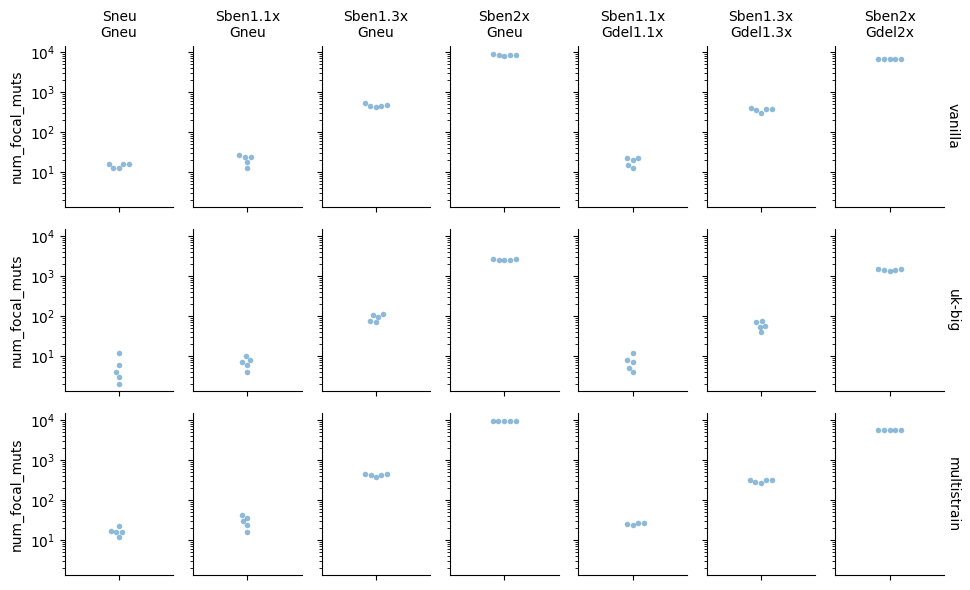

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+row_order=None+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+row_order=None+viz=catplot+y=num-focal-muts+ext=.png


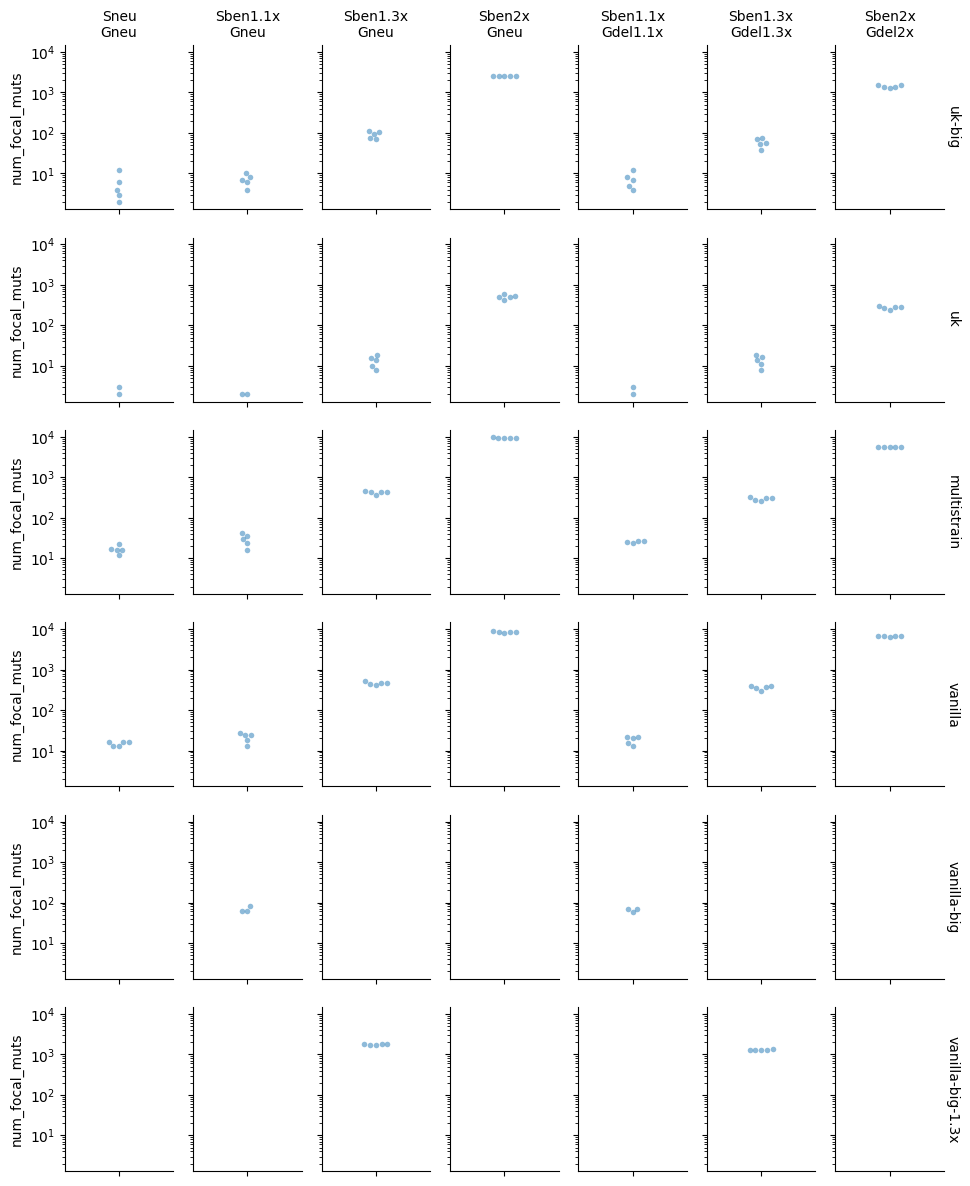

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=multistrain+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=multistrain+viz=catplot+y=num-focal-muts+ext=.png


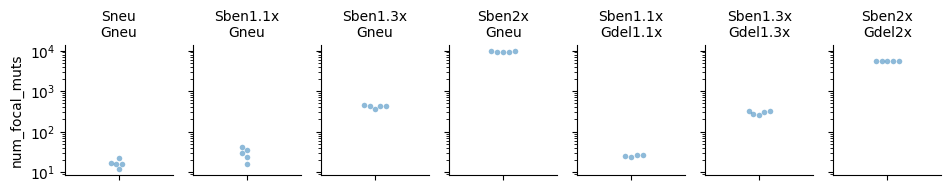

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk+viz=catplot+y=num-focal-muts+ext=.png


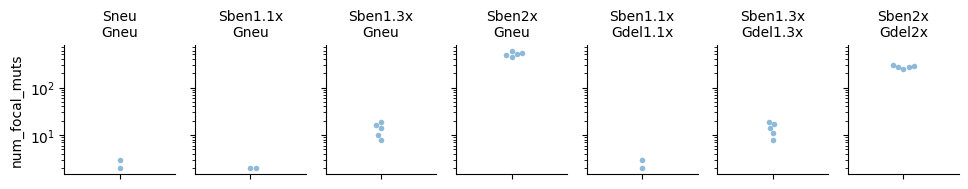

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk-big+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=uk-big+viz=catplot+y=num-focal-muts+ext=.png


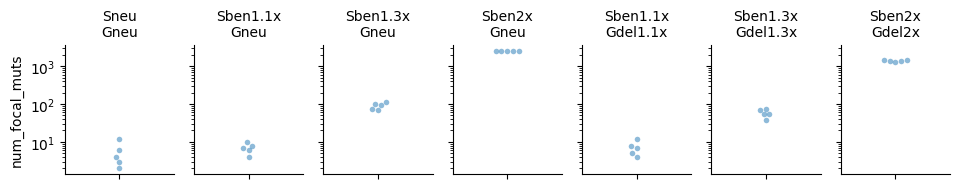

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla+viz=catplot+y=num-focal-muts+ext=.png


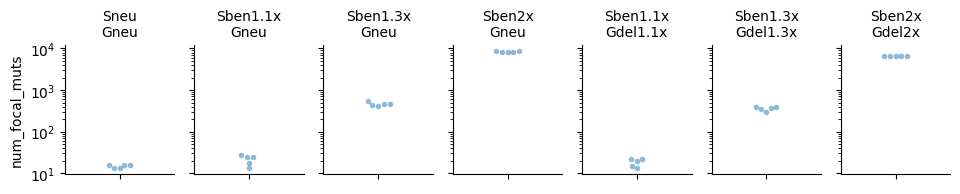

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big+viz=catplot+y=num-focal-muts+ext=.png


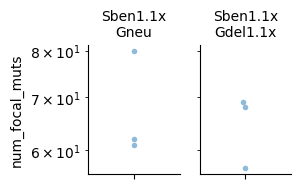

teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+source_name=vanilla-big-1.3x+viz=catplot+y=num-focal-muts+ext=.png


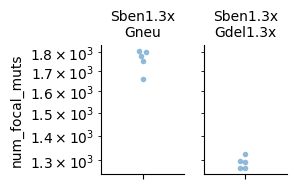

In [12]:
data = results_df[
    (results_df["trt_hsurf_bits"] == 0)
    & (
        results_df["trt_n_downsample"]
        == results_df.groupby(["trt_name", "source_name"])[
            "trt_n_downsample"
        ].transform("max")
    )
]

for row_order in ["vanilla", "uk-big", "multistrain"], None:
    with tp.teed(
        sns.catplot,
        data=data,
        y="num_focal_muts",
        col="trt_name_",
        row="source_name",
        col_order=col_order,
        row_order=row_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        alpha=0.5,
        height=2,
        aspect=0.7,
        size=4,
        teeplot_outattrs={"row_order": opyt.apply_if(row_order, "_".join)},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("log")

            ax.set_xlabel("")

        teed.tight_layout()

for source_name, group_df in data.groupby("source_name"):
    with tp.teed(
        sns.catplot,
        data=group_df,
        y="num_focal_muts",
        col="trt_name_",
        col_order=filter(set(group_df["trt_name_"]).__contains__, col_order),
        legend=False,
        kind="swarm",
        margin_titles=True,
        alpha=0.5,
        height=2,
        aspect=0.7,
        size=4,
        teeplot_outattrs={"source_name": source_name},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("log")

            ax.set_xlabel("")
